In [1]:
!pip install shap

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap


In [4]:
ckd = pd.read_csv("kidney_disease.csv")

print(ckd.shape)
print(ckd.columns)

(400, 26)
Index(['id', 'age', 'bp', 'sg', 'al', 'su', 'rbc', 'pc', 'pcc', 'ba', 'bgr',
       'bu', 'sc', 'sod', 'pot', 'hemo', 'pcv', 'wc', 'rc', 'htn', 'dm', 'cad',
       'appet', 'pe', 'ane', 'classification'],
      dtype='object')


In [5]:
ckd.columns = ckd.columns.str.strip().str.lower()

In [6]:
ckd = ckd.drop('id', axis=1)

In [7]:
ckd = ckd.applymap(lambda x: x.strip() if isinstance(x, str) else x)

/tmp/ipykernel_7203/2244097823.py:1: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  ckd = ckd.applymap(lambda x: x.strip() if isinstance(x, str) else x)


In [8]:
ckd = ckd.replace({
    'yes': 1, 'no': 0,
    'present': 1, 'notpresent': 0,
    'ckd': 1, 'notckd': 0,
    'good': 1, 'poor': 0,
    'normal': 1, 'abnormal': 0
})

/tmp/ipykernel_7203/1746768575.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  ckd = ckd.replace({


In [9]:
for col in ckd.columns:
    ckd[col] = pd.to_numeric(ckd[col], errors='coerce')

In [10]:
print(ckd.isnull().sum())

age                 9
bp                 12
sg                 47
al                 46
su                 49
rbc               152
pc                 65
pcc                 4
ba                  4
bgr                44
bu                 19
sc                 17
sod                87
pot                88
hemo               52
pcv                71
wc                106
rc                131
htn                 2
dm                  2
cad                 2
appet               1
pe                  1
ane                 1
classification      0
dtype: int64


In [11]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='mean')
ckd = pd.DataFrame(imputer.fit_transform(ckd), columns=ckd.columns)

In [12]:
X = ckd.drop('classification', axis=1)
y = ckd['classification']

In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [14]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [21]:
explainer = shap.Explainer(model, X_train)

In [22]:
shap_values = explainer(X_test)

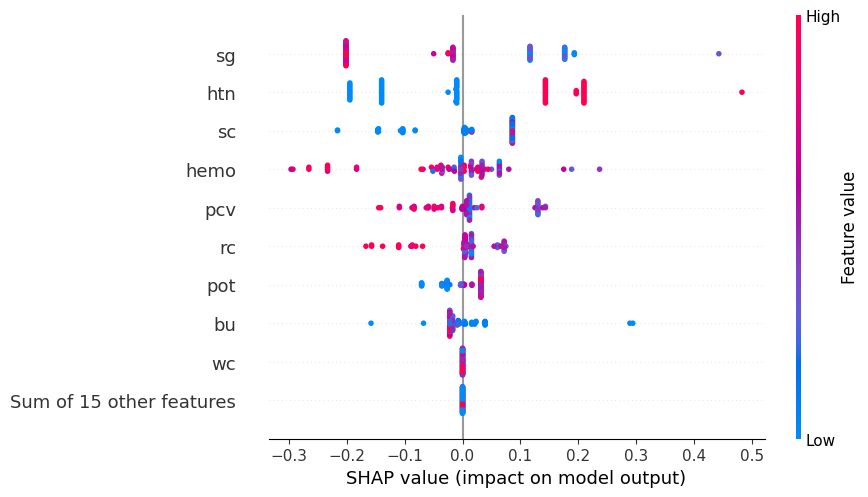

In [24]:
shap.plots.beeswarm(shap_values[:, :, 1])

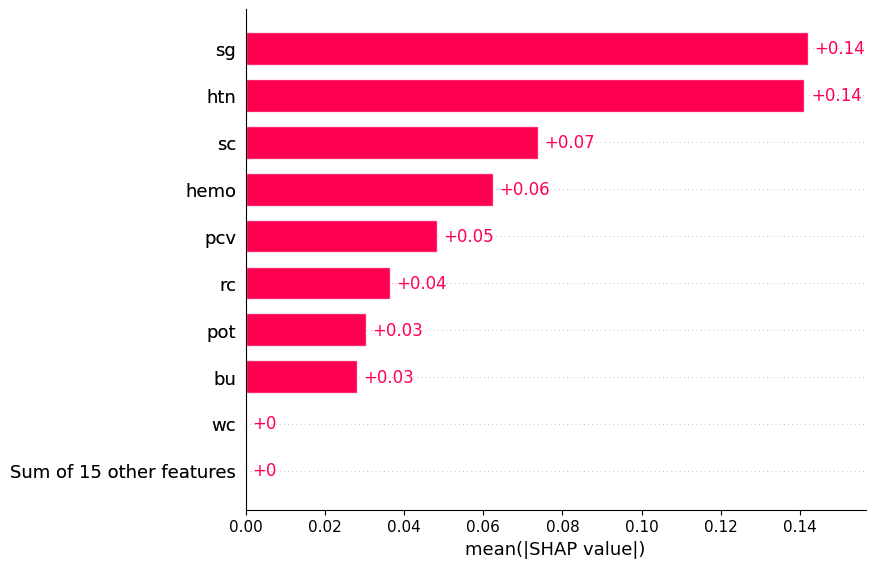

In [25]:
shap.plots.bar(shap_values[:, :, 1])

In [29]:
shap.plots.beeswarm(shap_values[:, :, 1], show=False)

plt.savefig("shap_summary_ckd.png", dpi=150, bbox_inches='tight')
plt.close()

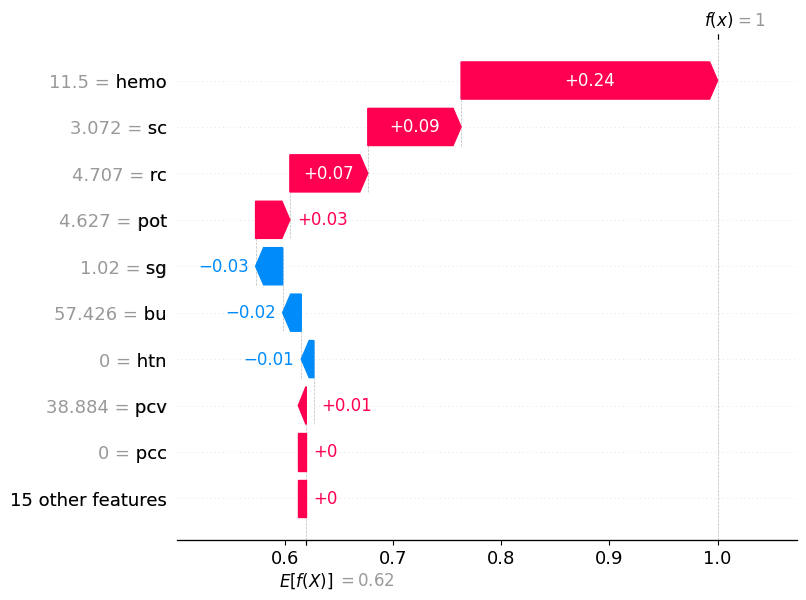

In [27]:
sample_index = 0

shap.plots.waterfall(shap_values[sample_index, :, 1])

In [28]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 1.0
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00        28
         1.0       1.00      1.00      1.00        52

    accuracy                           1.00        80
   macro avg       1.00      1.00      1.00        80
weighted avg       1.00      1.00      1.00        80

